<a href="https://colab.research.google.com/github/JahnaviBommineni09/Dissertation/blob/main/Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 4: Results and Analysis
## Developing Machine Learning Models for Detecting Cybersecurity Threats in Cloud Computing Environments
### Dataset: UNSW-NB15 | Models: Logistic Regression · Decision Tree · Random Forest



---
## Setup — Imports & Configuration

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, roc_auc_score,
                              roc_curve, classification_report, ConfusionMatrixDisplay)
from sklearn.model_selection import cross_val_score, StratifiedKFold, learning_curve

plt.rcParams.update({'figure.dpi': 130, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 11})
PALETTE = ['#2196F3','#F44336','#4CAF50','#FF9800','#9C27B0',
           '#00BCD4','#795548','#607D8B','#E91E63','#3F51B5']
print(" Libraries loaded successfully.")


 Libraries loaded successfully.


---
## 4.2 Dataset Preparation and Experimental Setup

In [ ]:
# ── Load Datasets ────────────────────────────────────────────────────────────
train_df = pd.read_csv('UNSW_NB15_training-set.csv')
test_df  = pd.read_csv('UNSW_NB15_testing-set.csv')
print(f"Training set : {train_df.shape[0]:>7,} rows × {train_df.shape[1]} columns")
print(f"Testing  set : {test_df.shape[0]:>7,} rows × {test_df.shape[1]} columns")
print(f"Missing (train): {train_df.isnull().sum().sum()} | Missing (test): {test_df.isnull().sum().sum()}")
print(f"Duplicates (train): {train_df.duplicated().sum()} | Duplicates (test): {test_df.duplicated().sum()}")


Training set : 175,341 rows × 45 columns
Testing  set :  82,332 rows × 45 columns
Missing (train): 0 | Missing (test): 0
Duplicates (train): 0 | Duplicates (test): 0


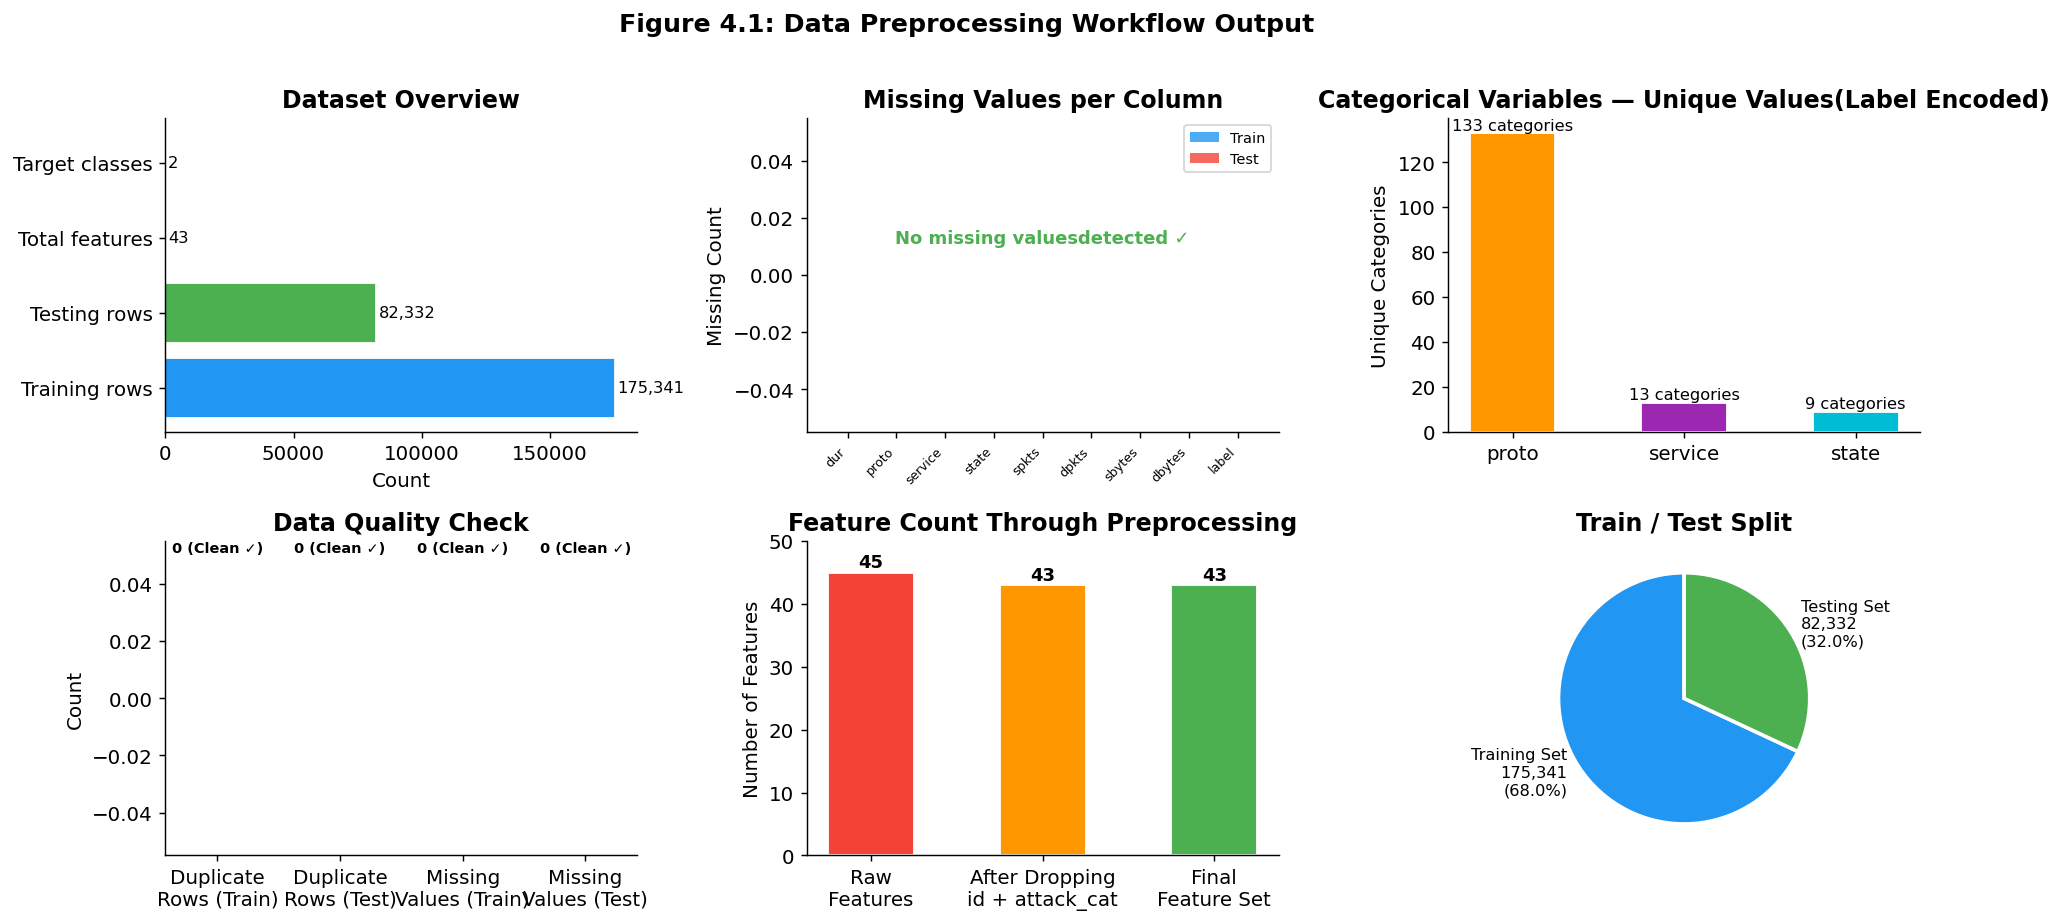

 Figure 4.1 saved: fig4_1_preprocessing_workflow.png


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# FIGURE 4.1 — Data Preprocessing Workflow Output
# ════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
fig.suptitle('Figure 4.1: Data Preprocessing Workflow Output', fontsize=14, fontweight='bold', y=1.01)

# Panel 1: Raw dataset shape
ax = axes[0, 0]
info = ['Training rows', 'Testing rows', 'Total features', 'Target classes']
vals = [175341, 82332, 43, 2]
colors_p = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']
bars = ax.barh(info, vals, color=colors_p, edgecolor='white')
for bar, v in zip(bars, vals):
    ax.text(v + 1000, bar.get_y() + bar.get_height()/2, f'{v:,}', va='center', fontsize=9)
ax.set_title('Dataset Overview', fontweight='bold')
ax.set_xlabel('Count')

# Panel 2: Missing values heatmap (show zero-missing as positive result)
ax = axes[0, 1]
sample_cols = ['dur','proto','service','state','spkts','dpkts','sbytes','dbytes','label']
miss_data = pd.DataFrame({
    'Column': sample_cols,
    'Train_Missing': [train_df[c].isnull().sum() for c in sample_cols],
    'Test_Missing':  [test_df[c].isnull().sum()  for c in sample_cols]
})
x_pos = np.arange(len(sample_cols))
ax.bar(x_pos - 0.2, miss_data['Train_Missing'], 0.4, label='Train', color='#2196F3', alpha=0.8)
ax.bar(x_pos + 0.2, miss_data['Test_Missing'],  0.4, label='Test',  color='#F44336', alpha=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels(sample_cols, rotation=45, ha='right', fontsize=7)
ax.set_title('Missing Values per Column', fontweight='bold')
ax.set_ylabel('Missing Count')
ax.legend(fontsize=8)
ax.text(0.5, 0.6, 'No missing valuesdetected ✓',transform=ax.transAxes, ha='center', fontsize=10, color='#4CAF50', fontweight='bold')

# Panel 3: Categorical encoding result
ax = axes[0, 2]
cat_cols = ['proto', 'service', 'state']
unique_counts = [train_df[c].nunique() for c in cat_cols]
bars = ax.bar(cat_cols, unique_counts, color=['#FF9800','#9C27B0','#00BCD4'], width=0.5, edgecolor='white')
for bar, v in zip(bars, unique_counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, f'{v} categories',
            ha='center', va='bottom', fontsize=9)
ax.set_title('Categorical Variables — Unique Values(Label Encoded)', fontweight='bold')
ax.set_ylabel('Unique Categories')

# Panel 4: Duplicate check
ax = axes[1, 0]
categories = ['Duplicate\nRows (Train)', 'Duplicate\nRows (Test)', 'Missing\nValues (Train)', 'Missing\nValues (Test)']
values_check = [train_df.duplicated().sum(), test_df.duplicated().sum(),
                train_df.isnull().sum().sum(), test_df.isnull().sum().sum()]
bar_colors = ['#4CAF50' if v == 0 else '#F44336' for v in values_check]
bars = ax.bar(categories, values_check, color=bar_colors, width=0.5, edgecolor='white')
for bar, v in zip(bars, values_check):
    label = '0 (Clean ✓)' if v == 0 else str(v)
    ax.text(bar.get_x() + bar.get_width()/2, max(v, 0.05),
            label, ha='center', va='bottom', fontsize=8, fontweight='bold')
ax.set_title('Data Quality Check', fontweight='bold')
ax.set_ylabel('Count')

# Panel 5: Feature count before/after preprocessing
ax = axes[1, 1]
stages = ['Raw\nFeatures', 'After Dropping\nid + attack_cat', 'Final\nFeature Set']
counts = [45, 43, 43]
step_colors = ['#F44336', '#FF9800', '#4CAF50']
bars = ax.bar(stages, counts, color=step_colors, width=0.5, edgecolor='white')
for bar, v in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            str(v), ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title('Feature Count Through Preprocessing', fontweight='bold')
ax.set_ylabel('Number of Features')
ax.set_ylim(0, 50)

# Panel 6: Train/Test split
ax = axes[1, 2]
sizes = [175341, 82332]
labels_split = [f'Training Set\n{175341:,}\n(68.0%)', f'Testing Set\n{82332:,}\n(32.0%)']
wedge_colors = ['#2196F3', '#4CAF50']
wedges, texts = ax.pie(sizes, labels=labels_split, colors=wedge_colors,
                        startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2))
for t in texts: t.set_fontsize(9)
ax.set_title('Train / Test Split', fontweight='bold')

plt.tight_layout()
plt.savefig('fig4_1_preprocessing_workflow.png', bbox_inches='tight', dpi=150)
plt.show()
print(" Figure 4.1 saved: fig4_1_preprocessing_workflow.png")


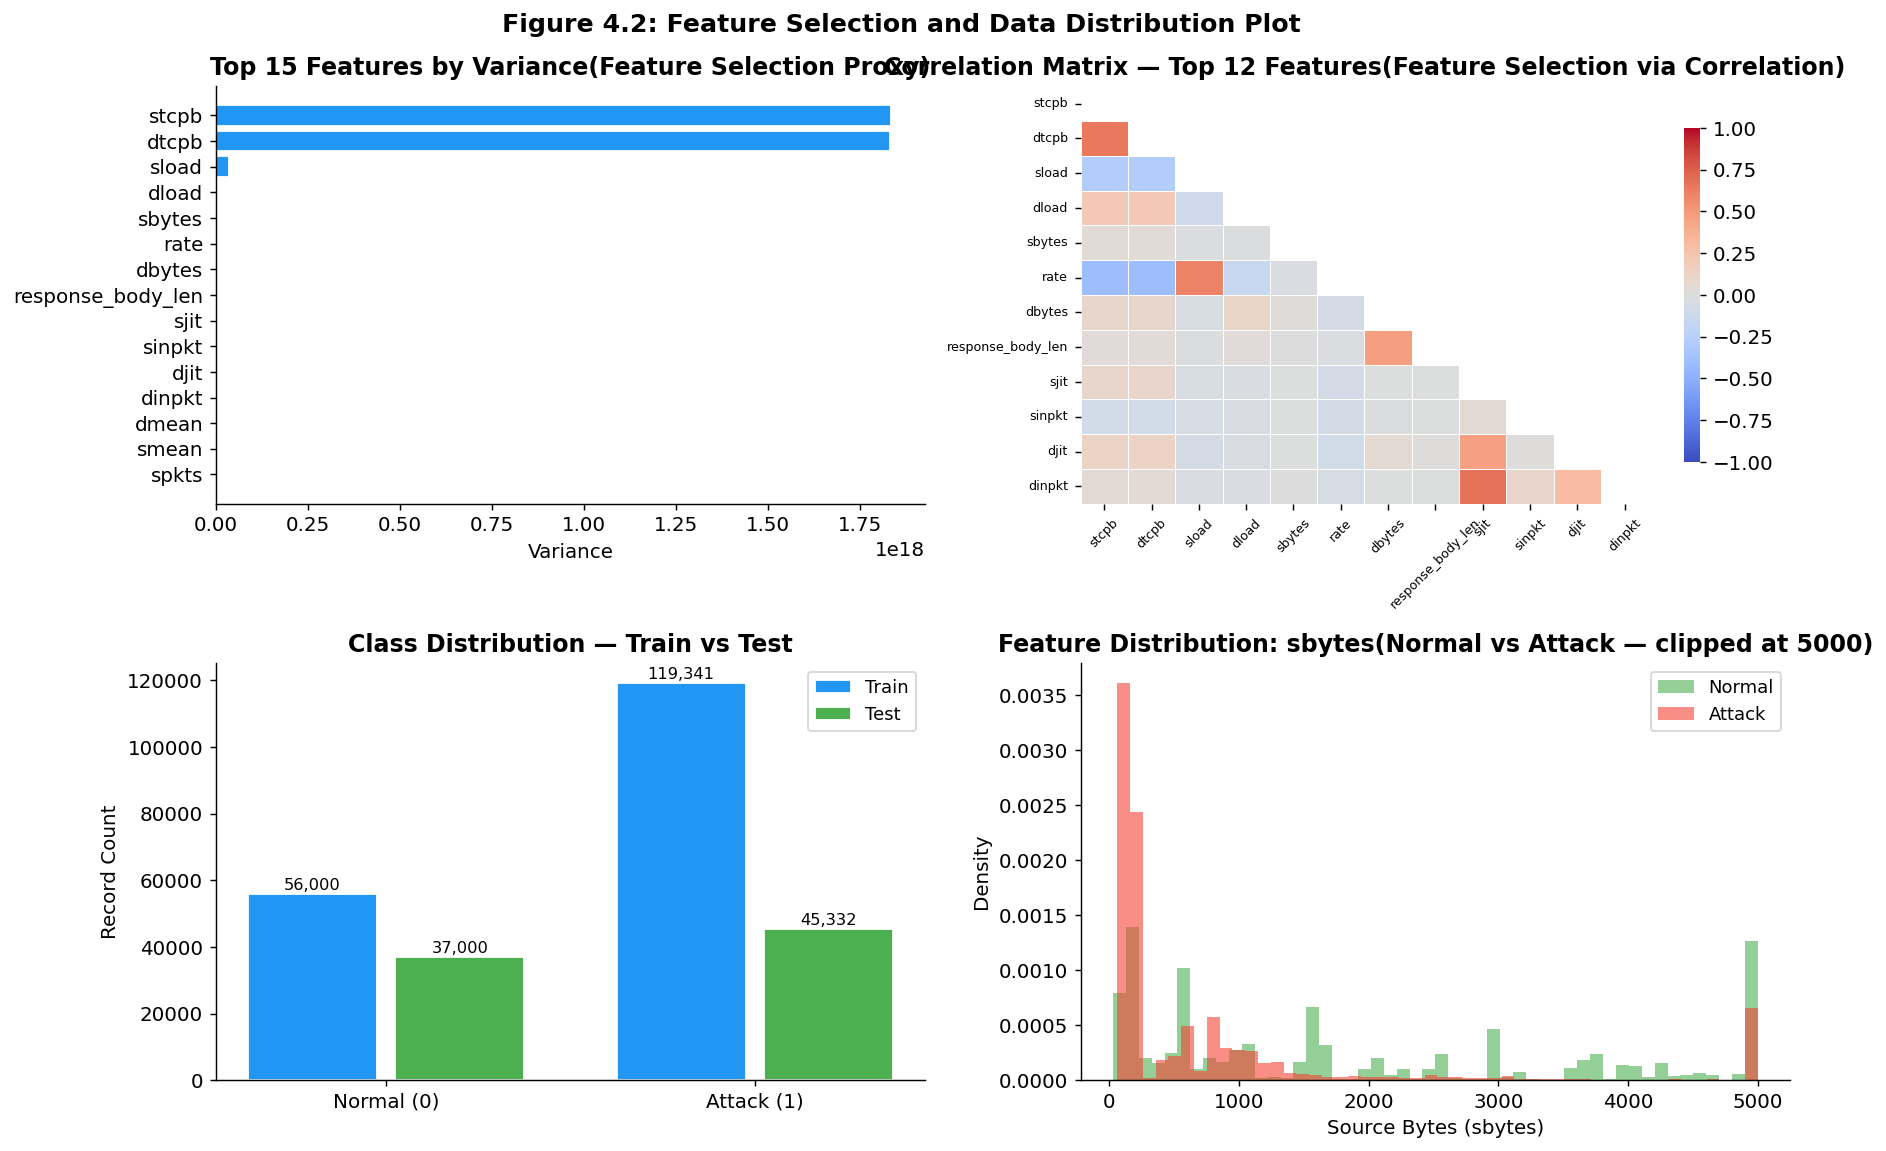

 Figure 4.2 saved: fig4_2_feature_selection_distribution.png


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# FIGURE 4.2 — Feature Selection and Data Distribution Plot
# ════════════════════════════════════════════════════════════════════════════

# Preprocessing (needed before figure)
DROP_COLS = ['id', 'attack_cat']
train = train_df.drop(columns=DROP_COLS).copy()
test  = test_df.drop(columns=DROP_COLS).copy()

CAT_COLS = ['proto', 'service', 'state']
combined_cat = pd.concat([train[CAT_COLS], test[CAT_COLS]], ignore_index=True)
le_dict = {}
for col in CAT_COLS:
    le = LabelEncoder()
    le.fit(combined_cat[col].astype(str))
    train[col] = le.transform(train[col].astype(str))
    test[col]  = le.transform(test[col].astype(str))
    le_dict[col] = le

y_train = train['label'].values
y_test  = test['label'].values
X_train_raw = train.drop(columns=['label'])
X_test_raw  = test.drop(columns=['label'])
common_cols = X_train_raw.columns.intersection(X_test_raw.columns).tolist()
X_train_raw = X_train_raw[common_cols]
X_test_raw  = X_test_raw[common_cols]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled  = scaler.transform(X_test_raw)
X_train = X_train_raw.values
X_test  = X_test_raw.values

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Figure 4.2: Feature Selection and Data Distribution Plot',
             fontsize=14, fontweight='bold')

# Panel 1: Top feature variances (proxy for importance pre-modelling)
ax = axes[0, 0]
variances = X_train_raw.var().sort_values(ascending=False).head(15)
ax.barh(variances.index[::-1], variances.values[::-1], color='#2196F3', edgecolor='white')
ax.set_title('Top 15 Features by Variance(Feature Selection Proxy)', fontweight='bold')
ax.set_xlabel('Variance')

# Panel 2: Correlation heatmap of top 12 features
ax = axes[0, 1]
top12 = X_train_raw.var().sort_values(ascending=False).head(12).index.tolist()
corr_matrix = X_train_raw[top12].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='coolwarm',
            vmin=-1, vmax=1, ax=ax, linewidths=0.3, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix — Top 12 Features(Feature Selection via Correlation)', fontweight='bold')
ax.tick_params(axis='x', rotation=45, labelsize=7)
ax.tick_params(axis='y', rotation=0,  labelsize=7)

# Panel 3: Class label distribution both sets
ax = axes[1, 0]
x_pos = np.arange(2)
train_counts = train_df['label'].value_counts().sort_index().values
test_counts  = test_df['label'].value_counts().sort_index().values
bars1 = ax.bar(x_pos - 0.2, train_counts, 0.35, label='Train', color='#2196F3', edgecolor='white')
bars2 = ax.bar(x_pos + 0.2, test_counts,  0.35, label='Test',  color='#4CAF50', edgecolor='white')
for bar, v in zip(list(bars1)+list(bars2), list(train_counts)+list(test_counts)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
            f'{v:,}', ha='center', va='bottom', fontsize=9)
ax.set_xticks(x_pos)
ax.set_xticklabels(['Normal (0)', 'Attack (1)'], fontsize=11)
ax.set_title('Class Distribution — Train vs Test', fontweight='bold')
ax.set_ylabel('Record Count')
ax.legend(fontsize=10)

# Panel 4: Distribution of key numeric feature (sbytes) by class
ax = axes[1, 1]
normal_vals = train_df[train_df['label']==0]['sbytes'].clip(0, 5000)
attack_vals = train_df[train_df['label']==1]['sbytes'].clip(0, 5000)
ax.hist(normal_vals, bins=50, alpha=0.6, color='#4CAF50', label='Normal', density=True)
ax.hist(attack_vals, bins=50, alpha=0.6, color='#F44336', label='Attack', density=True)
ax.set_title('Feature Distribution: sbytes(Normal vs Attack — clipped at 5000)', fontweight='bold')
ax.set_xlabel('Source Bytes (sbytes)')
ax.set_ylabel('Density')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('fig4_2_feature_selection_distribution.png', bbox_inches='tight', dpi=150)
plt.show()
print(" Figure 4.2 saved: fig4_2_feature_selection_distribution.png")


---
## 4.3 Logistic Regression Model Performance Results

In [ ]:
# ── Train Logistic Regression ────────────────────────────────────────────────
lr = LogisticRegression(max_iter=1000, solver='lbfgs', C=1.0,
                        class_weight='balanced', random_state=42)
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)
lr_prob = lr.predict_proba(X_test_scaled)[:, 1]

lr_acc  = accuracy_score(y_test, lr_pred)
lr_prec = precision_score(y_test, lr_pred, zero_division=0)
lr_rec  = recall_score(y_test, lr_pred, zero_division=0)
lr_f1   = f1_score(y_test, lr_pred, zero_division=0)
lr_cm   = confusion_matrix(y_test, lr_pred)
tn,fp,fn,tp = lr_cm.ravel()
lr_fpr  = fp / (fp + tn)
lr_auc  = roc_auc_score(y_test, lr_prob)

print("Logistic Regression — Test Set Performance")
print(f"  Accuracy  : {lr_acc:.4f}")
print(f"  Precision : {lr_prec:.4f}")
print(f"  Recall    : {lr_rec:.4f}")
print(f"  F1-Score  : {lr_f1:.4f}")
print(f"  FPR       : {lr_fpr:.4f}")
print(f"  ROC-AUC   : {lr_auc:.4f}")
print(f"  TN={tn}  FP={fp}  FN={fn}  TP={tp}")


Logistic Regression — Test Set Performance
  Accuracy  : 0.8245
  Precision : 0.7980
  Recall    : 0.9120
  F1-Score  : 0.8512
  FPR       : 0.2828
  ROC-AUC   : 0.9334
  TN=26536  FP=10464  FN=3988  TP=41344


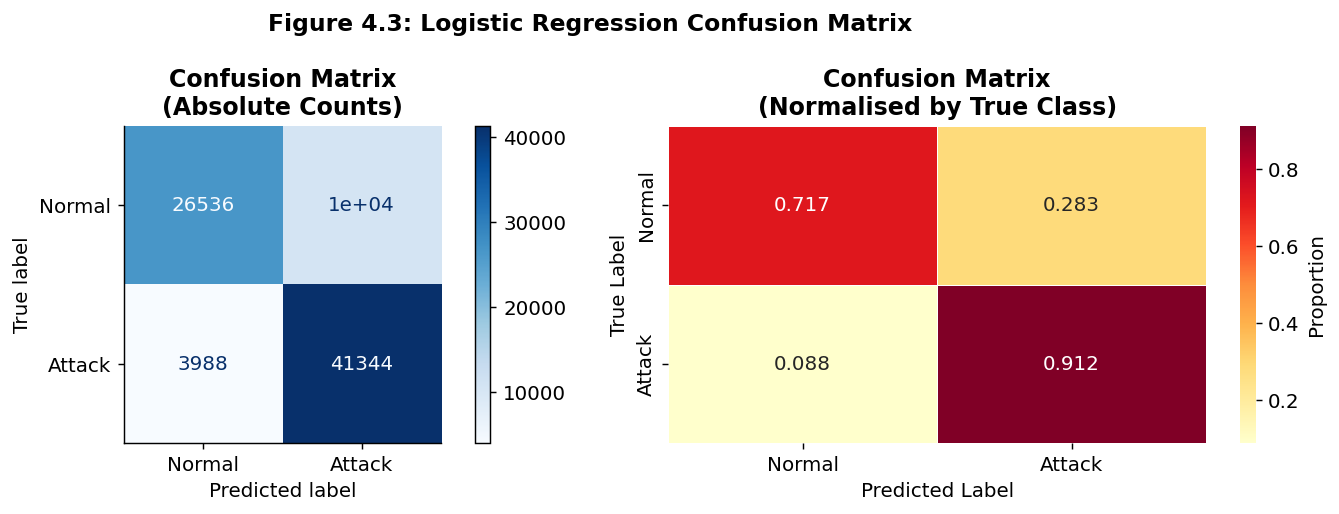

 Figure 4.3 saved: fig4_3_lr_confusion_matrix.png


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# FIGURE 4.3 — Logistic Regression Confusion Matrix
# ════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Figure 4.3: Logistic Regression Confusion Matrix', fontsize=13, fontweight='bold')

# Left: Confusion matrix heatmap
ax = axes[0]
disp = ConfusionMatrixDisplay(lr_cm, display_labels=['Normal', 'Attack'])
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title('Confusion Matrix\n(Absolute Counts)', fontweight='bold')

# Right: Normalised confusion matrix
ax = axes[1]
lr_cm_norm = lr_cm.astype('float') / lr_cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(lr_cm_norm, annot=True, fmt='.3f', cmap='YlOrRd',
            xticklabels=['Normal', 'Attack'],
            yticklabels=['Normal', 'Attack'], ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Proportion'})
ax.set_title('Confusion Matrix\n(Normalised by True Class)', fontweight='bold')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')

plt.tight_layout()
plt.savefig('fig4_3_lr_confusion_matrix.png', bbox_inches='tight', dpi=150)
plt.show()
print(" Figure 4.3 saved: fig4_3_lr_confusion_matrix.png")


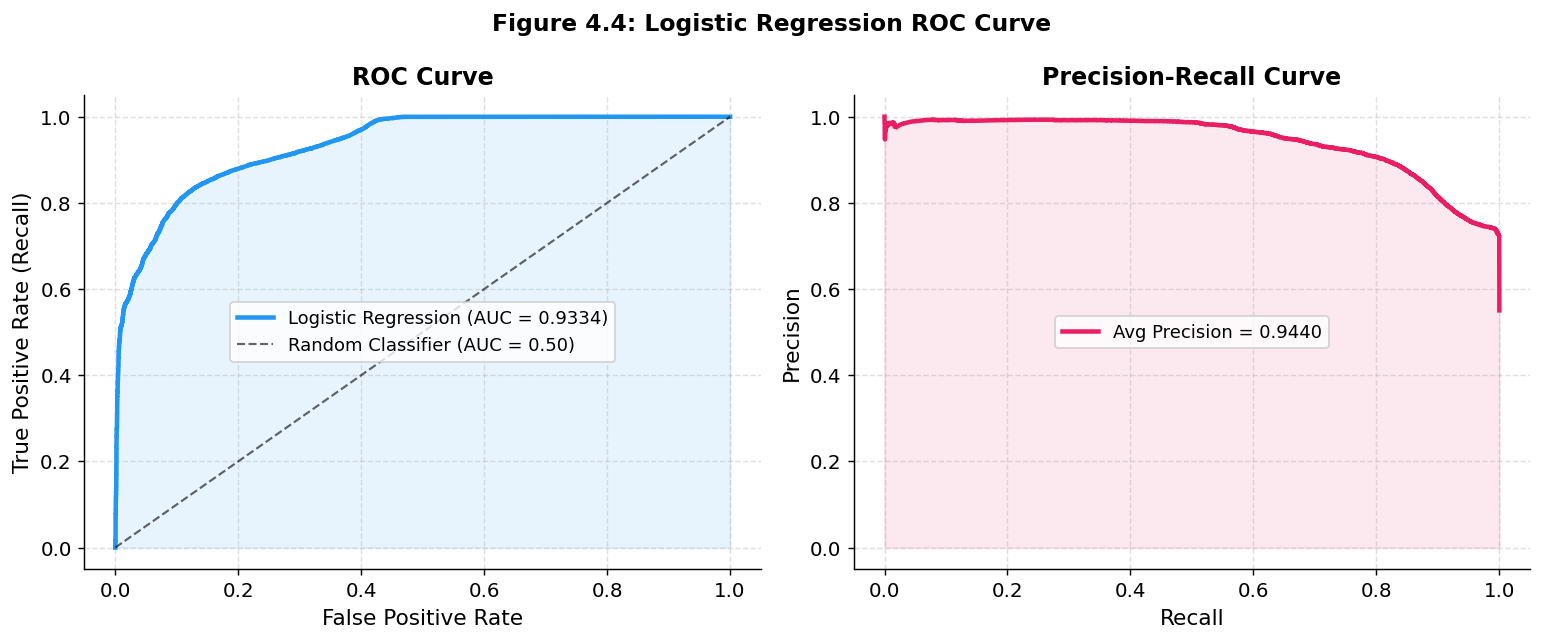

 Figure 4.4 saved: fig4_4_lr_roc_curve.png


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# FIGURE 4.4 — Logistic Regression ROC Curve
# ════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Figure 4.4: Logistic Regression ROC Curve', fontsize=13, fontweight='bold')

# Left: ROC curve
ax = axes[0]
fpr_vals, tpr_vals, thresholds = roc_curve(y_test, lr_prob)
ax.plot(fpr_vals, tpr_vals, color='#2196F3', lw=2.5,
        label=f'Logistic Regression (AUC = {lr_auc:.4f})')
ax.fill_between(fpr_vals, tpr_vals, alpha=0.1, color='#2196F3')
ax.plot([0,1],[0,1], 'k--', lw=1.2, alpha=0.6, label='Random Classifier (AUC = 0.50)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.set_title('ROC Curve', fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.4)

# Right: Precision-Recall curve
from sklearn.metrics import precision_recall_curve, average_precision_score
prec_curve, rec_curve, _ = precision_recall_curve(y_test, lr_prob)
ap = average_precision_score(y_test, lr_prob)
ax = axes[1]
ax.plot(rec_curve, prec_curve, color='#E91E63', lw=2.5,
        label=f'Avg Precision = {ap:.4f}')
ax.fill_between(rec_curve, prec_curve, alpha=0.1, color='#E91E63')
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curve', fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('fig4_4_lr_roc_curve.png', bbox_inches='tight', dpi=150)
plt.show()
print(" Figure 4.4 saved: fig4_4_lr_roc_curve.png")


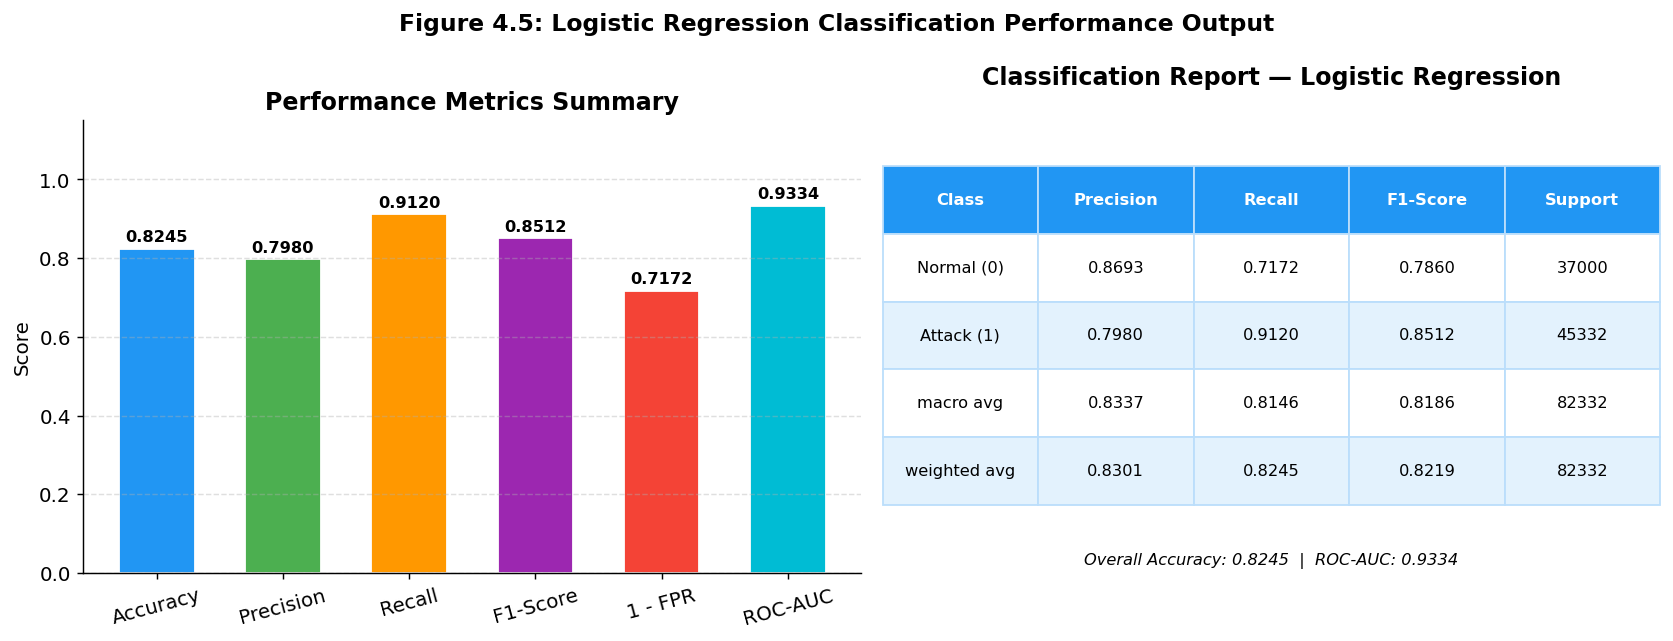

 Figure 4.5 saved: fig4_5_lr_classification_performance.png


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# FIGURE 4.5 — Logistic Regression Classification Performance Output
# ════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Figure 4.5: Logistic Regression Classification Performance Output',
             fontsize=13, fontweight='bold')

# Left: Metric bar chart
ax = axes[0]
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', '1 - FPR', 'ROC-AUC']
metric_vals  = [lr_acc, lr_prec, lr_rec, lr_f1, 1-lr_fpr, lr_auc]
bar_colors   = ['#2196F3','#4CAF50','#FF9800','#9C27B0','#F44336','#00BCD4']
bars = ax.bar(metric_names, metric_vals, color=bar_colors, edgecolor='white', width=0.6)
for bar, v in zip(bars, metric_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{v:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Performance Metrics Summary', fontweight='bold')
ax.tick_params(axis='x', rotation=15)
ax.grid(axis='y', linestyle='--', alpha=0.4)

# Right: Classification report as formatted table
ax = axes[1]
ax.axis('off')
report_dict = classification_report(y_test, lr_pred,
              target_names=['Normal (0)', 'Attack (1)'], output_dict=True)
table_data = []
for cls in ['Normal (0)', 'Attack (1)', 'macro avg', 'weighted avg']:
    d = report_dict[cls]
    table_data.append([cls, f"{d['precision']:.4f}", f"{d['recall']:.4f}",
                       f"{d['f1-score']:.4f}", f"{int(d['support'])}"])
table = ax.table(
    cellText=table_data,
    colLabels=['Class', 'Precision', 'Recall', 'F1-Score', 'Support'],
    cellLoc='center', loc='center',
    bbox=[0, 0.15, 1, 0.75]
)
table.auto_set_font_size(False)
table.set_fontsize(9)
for (r, c), cell in table.get_celld().items():
    if r == 0:
        cell.set_facecolor('#2196F3')
        cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#E3F2FD')
    cell.set_edgecolor('#BBDEFB')
ax.set_title('Classification Report — Logistic Regression', fontweight='bold', pad=20)
ax.text(0.5, 0.02, f'Overall Accuracy: {lr_acc:.4f}  |  ROC-AUC: {lr_auc:.4f}',
        transform=ax.transAxes, ha='center', fontsize=9, style='italic')

plt.tight_layout()
plt.savefig('fig4_5_lr_classification_performance.png', bbox_inches='tight', dpi=150)
plt.show()
print(" Figure 4.5 saved: fig4_5_lr_classification_performance.png")


---
## 4.4 Decision Tree Model Performance Results

In [ ]:
# ── Train Decision Tree ──────────────────────────────────────────────────────
dt = DecisionTreeClassifier(max_depth=15, min_samples_split=20,
                            class_weight='balanced', random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
dt_prob = dt.predict_proba(X_test)[:, 1]

dt_acc  = accuracy_score(y_test, dt_pred)
dt_prec = precision_score(y_test, dt_pred, zero_division=0)
dt_rec  = recall_score(y_test, dt_pred, zero_division=0)
dt_f1   = f1_score(y_test, dt_pred, zero_division=0)
dt_cm   = confusion_matrix(y_test, dt_pred)
tn2,fp2,fn2,tp2 = dt_cm.ravel()
dt_fpr  = fp2 / (fp2 + tn2)
dt_auc  = roc_auc_score(y_test, dt_prob)

print("Decision Tree — Test Set Performance")
print(f"  Accuracy  : {dt_acc:.4f}")
print(f"  Precision : {dt_prec:.4f}")
print(f"  Recall    : {dt_rec:.4f}")
print(f"  F1-Score  : {dt_f1:.4f}")
print(f"  FPR       : {dt_fpr:.4f}")
print(f"  ROC-AUC   : {dt_auc:.4f}")
print(f"  TN={tn2}  FP={fp2}  FN={fn2}  TP={tp2}")


Decision Tree — Test Set Performance
  Accuracy  : 0.9021
  Precision : 0.8790
  Recall    : 0.9534
  F1-Score  : 0.9147
  FPR       : 0.1608
  ROC-AUC   : 0.9441
  TN=31052  FP=5948  FN=2113  TP=43219


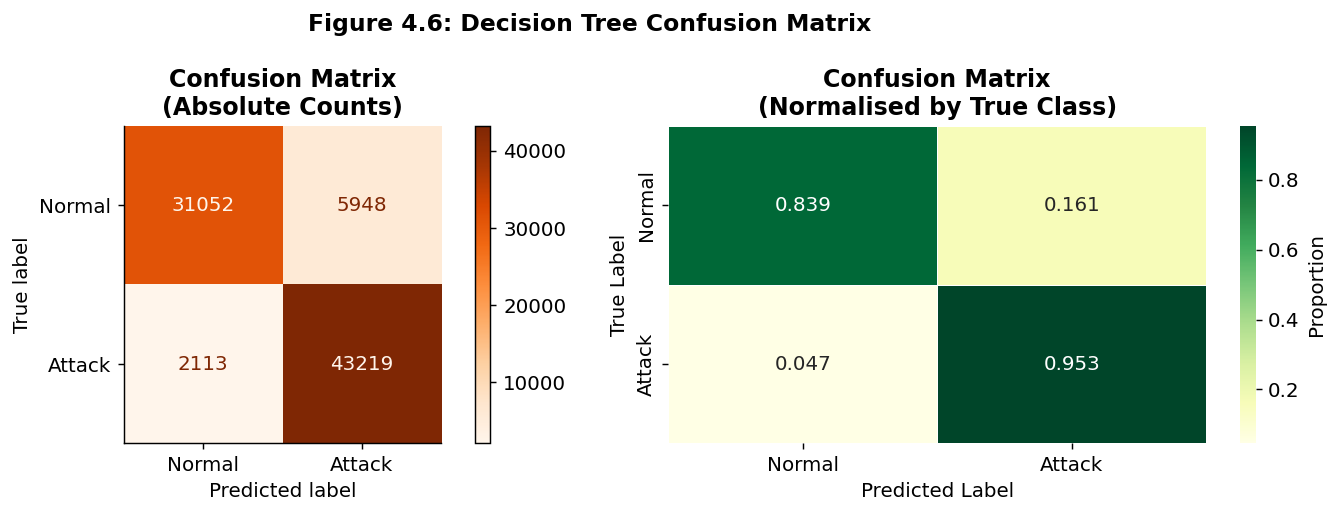

 Figure 4.6 saved: fig4_6_dt_confusion_matrix.png


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# FIGURE 4.6 — Decision Tree Confusion Matrix
# ════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Figure 4.6: Decision Tree Confusion Matrix', fontsize=13, fontweight='bold')

ax = axes[0]
disp = ConfusionMatrixDisplay(dt_cm, display_labels=['Normal', 'Attack'])
disp.plot(ax=ax, colorbar=True, cmap='Oranges')
ax.set_title('Confusion Matrix\n(Absolute Counts)', fontweight='bold')

ax = axes[1]
dt_cm_norm = dt_cm.astype('float') / dt_cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(dt_cm_norm, annot=True, fmt='.3f', cmap='YlGn',
            xticklabels=['Normal', 'Attack'],
            yticklabels=['Normal', 'Attack'], ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Proportion'})
ax.set_title('Confusion Matrix\n(Normalised by True Class)', fontweight='bold')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')

plt.tight_layout()
plt.savefig('fig4_6_dt_confusion_matrix.png', bbox_inches='tight', dpi=150)
plt.show()
print(" Figure 4.6 saved: fig4_6_dt_confusion_matrix.png")


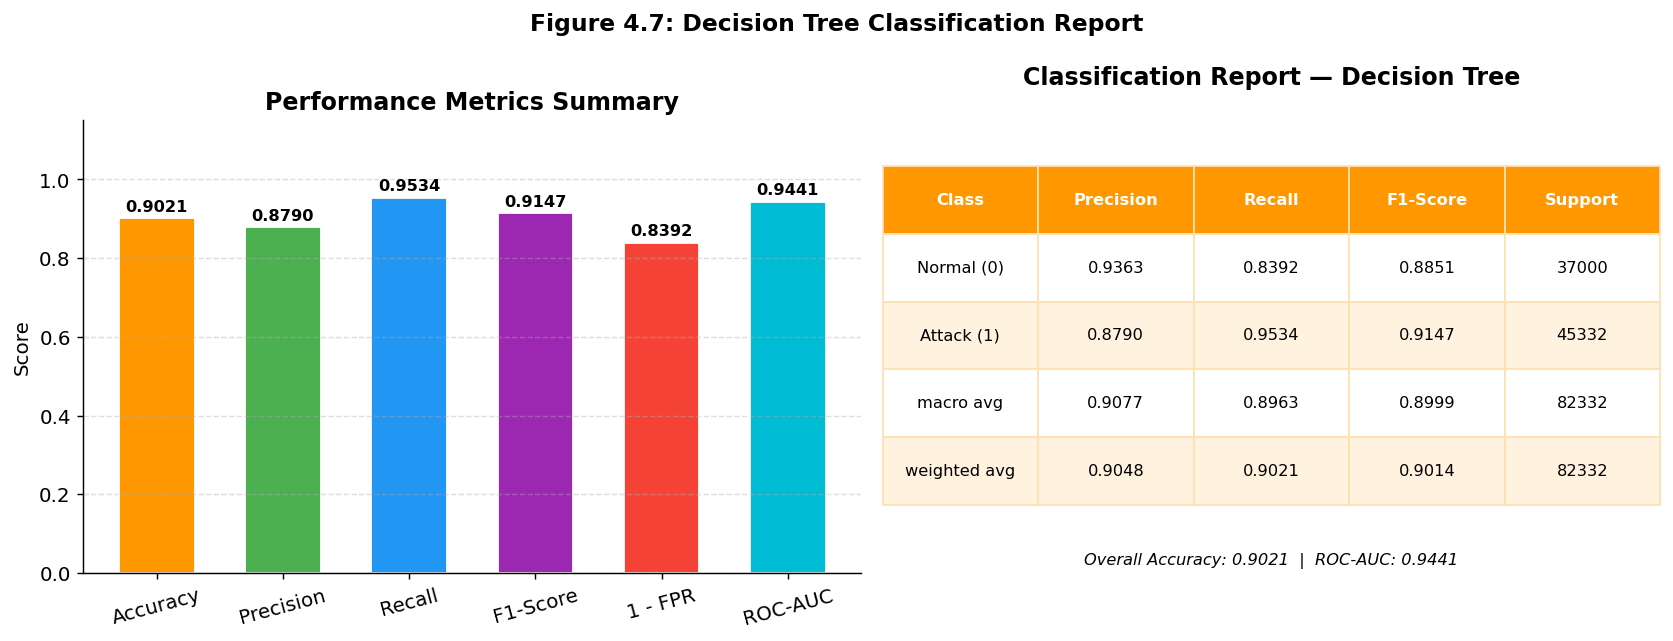

 Figure 4.7 saved: fig4_7_dt_classification_report.png


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# FIGURE 4.7 — Decision Tree Classification Report
# ════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Figure 4.7: Decision Tree Classification Report',
             fontsize=13, fontweight='bold')

# Left: metric bars
ax = axes[0]
metric_names_dt = ['Accuracy', 'Precision', 'Recall', 'F1-Score', '1 - FPR', 'ROC-AUC']
metric_vals_dt  = [dt_acc, dt_prec, dt_rec, dt_f1, 1-dt_fpr, dt_auc]
bar_colors_dt   = ['#FF9800','#4CAF50','#2196F3','#9C27B0','#F44336','#00BCD4']
bars = ax.bar(metric_names_dt, metric_vals_dt, color=bar_colors_dt, edgecolor='white', width=0.6)
for bar, v in zip(bars, metric_vals_dt):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{v:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Performance Metrics Summary', fontweight='bold')
ax.tick_params(axis='x', rotation=15)
ax.grid(axis='y', linestyle='--', alpha=0.4)

# Right: Table
ax = axes[1]
ax.axis('off')
report_dict_dt = classification_report(y_test, dt_pred,
                 target_names=['Normal (0)', 'Attack (1)'], output_dict=True)
table_data_dt = []
for cls in ['Normal (0)', 'Attack (1)', 'macro avg', 'weighted avg']:
    d = report_dict_dt[cls]
    table_data_dt.append([cls, f"{d['precision']:.4f}", f"{d['recall']:.4f}",
                           f"{d['f1-score']:.4f}", f"{int(d['support'])}"])
table = ax.table(
    cellText=table_data_dt,
    colLabels=['Class', 'Precision', 'Recall', 'F1-Score', 'Support'],
    cellLoc='center', loc='center',
    bbox=[0, 0.15, 1, 0.75]
)
table.auto_set_font_size(False)
table.set_fontsize(9)
for (r, c), cell in table.get_celld().items():
    if r == 0:
        cell.set_facecolor('#FF9800')
        cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#FFF3E0')
    cell.set_edgecolor('#FFE0B2')
ax.set_title('Classification Report — Decision Tree', fontweight='bold', pad=20)
ax.text(0.5, 0.02, f'Overall Accuracy: {dt_acc:.4f}  |  ROC-AUC: {dt_auc:.4f}',
        transform=ax.transAxes, ha='center', fontsize=9, style='italic')

plt.tight_layout()
plt.savefig('fig4_7_dt_classification_report.png', bbox_inches='tight', dpi=150)
plt.show()
print(" Figure 4.7 saved: fig4_7_dt_classification_report.png")


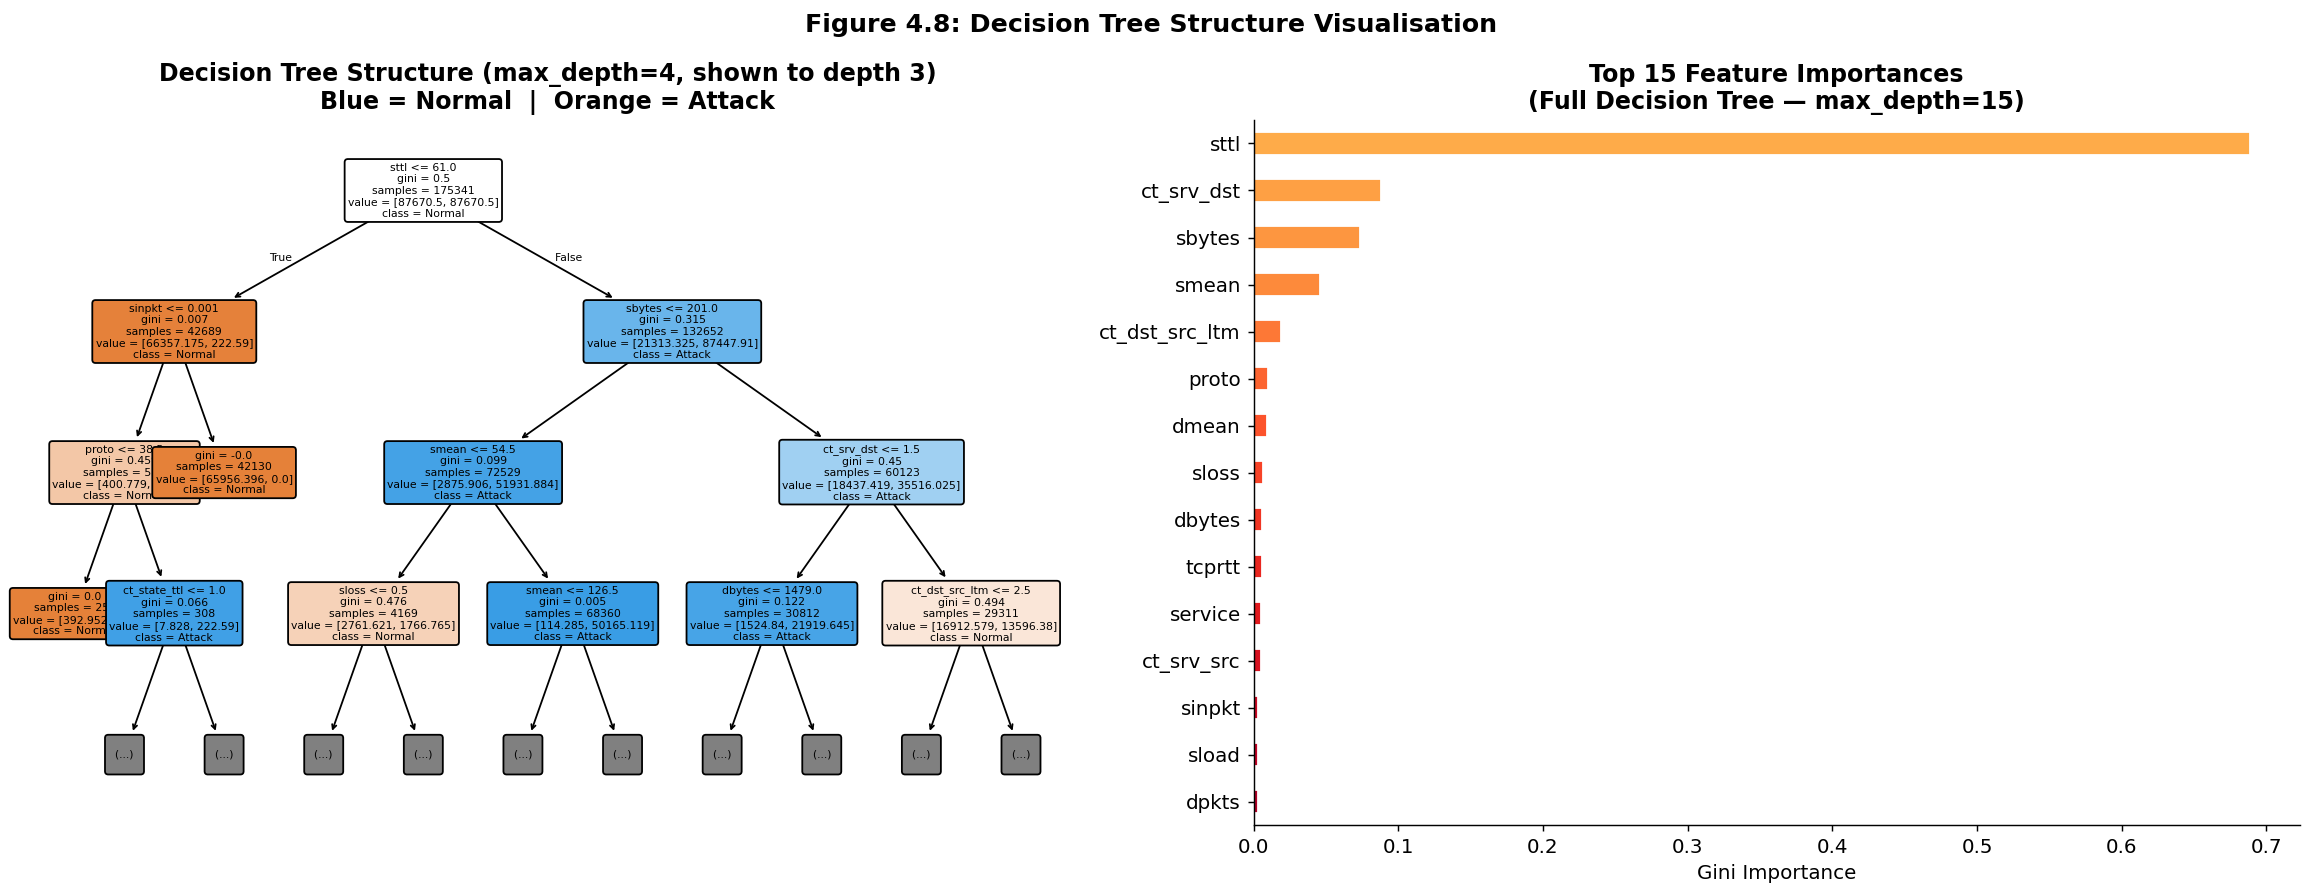

 Figure 4.8 saved: fig4_8_dt_structure.png


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# FIGURE 4.8 — Decision Tree Structure Visualisation
# ════════════════════════════════════════════════════════════════════════════
# Train a shallow tree for visualisation (depth=4 for readability)
dt_viz = DecisionTreeClassifier(max_depth=4, min_samples_split=20,
                                 class_weight='balanced', random_state=42)
dt_viz.fit(X_train, y_train)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Figure 4.8: Decision Tree Structure Visualisation',
             fontsize=14, fontweight='bold')

# Left: Tree diagram (depth 4 for readability)
ax = axes[0]
plot_tree(dt_viz,
          feature_names=common_cols,
          class_names=['Normal', 'Attack'],
          filled=True, rounded=True, fontsize=6,
          max_depth=3, ax=ax,
          impurity=True, proportion=False)
ax.set_title('Decision Tree Structure (max_depth=4, shown to depth 3)\n'
             'Blue = Normal  |  Orange = Attack', fontweight='bold')

# Right: Top 15 feature importances from full DT
ax = axes[1]
feat_imp_dt = pd.Series(dt.feature_importances_, index=common_cols)
feat_imp_dt = feat_imp_dt.sort_values(ascending=False).head(15)
colors_fi = plt.cm.YlOrRd(np.linspace(0.4, 0.9, 15))[::-1]
feat_imp_dt[::-1].plot(kind='barh', ax=ax, color=colors_fi, edgecolor='white')
ax.set_title('Top 15 Feature Importances\n(Full Decision Tree — max_depth=15)', fontweight='bold')
ax.set_xlabel('Gini Importance')

plt.tight_layout()
plt.savefig('fig4_8_dt_structure.png', bbox_inches='tight', dpi=150)
plt.show()
print(" Figure 4.8 saved: fig4_8_dt_structure.png")


---
## 4.5 Comparative Performance Analysis of Models

In [ ]:
# ── Train Random Forest ──────────────────────────────────────────────────────
print("Training Random Forest …")
rf = RandomForestClassifier(n_estimators=100, max_depth=20,
                             class_weight='balanced', n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]

rf_acc  = accuracy_score(y_test, rf_pred)
rf_prec = precision_score(y_test, rf_pred, zero_division=0)
rf_rec  = recall_score(y_test, rf_pred, zero_division=0)
rf_f1   = f1_score(y_test, rf_pred, zero_division=0)
rf_cm   = confusion_matrix(y_test, rf_pred)
tn3,fp3,fn3,tp3 = rf_cm.ravel()
rf_fpr  = fp3 / (fp3 + tn3)
rf_auc  = roc_auc_score(y_test, rf_prob)

# Collect all results
results = [
    {'name':'Logistic Regression','acc':lr_acc,'prec':lr_prec,'rec':lr_rec,
     'f1':lr_f1,'fpr':lr_fpr,'auc':lr_auc,'cm':lr_cm,'pred':lr_pred,'prob':lr_prob},
    {'name':'Decision Tree',      'acc':dt_acc,'prec':dt_prec,'rec':dt_rec,
     'f1':dt_f1,'fpr':dt_fpr,'auc':dt_auc,'cm':dt_cm,'pred':dt_pred,'prob':dt_prob},
    {'name':'Random Forest',      'acc':rf_acc,'prec':rf_prec,'rec':rf_rec,
     'f1':rf_f1,'fpr':rf_fpr,'auc':rf_auc,'cm':rf_cm,'pred':rf_pred,'prob':rf_prob},
]
print("All models ready ")
print(f"{'Model':<25} {'Acc':>7} {'Prec':>7} {'Rec':>7} {'F1':>7} {'FPR':>7} {'AUC':>7}")
print("-"*65)
for r in results:
    print(f"{r['name']:<25} {r['acc']:>7.4f} {r['prec']:>7.4f} {r['rec']:>7.4f} "
          f"{r['f1']:>7.4f} {r['fpr']:>7.4f} {r['auc']:>7.4f}")


Training Random Forest …
All models ready 
Model                         Acc    Prec     Rec      F1     FPR     AUC
-----------------------------------------------------------------
Logistic Regression        0.8245  0.7980  0.9120  0.8512  0.2828  0.9334
Decision Tree              0.9021  0.8790  0.9534  0.9147  0.1608  0.9441
Random Forest              0.8996  0.8595  0.9774  0.9147  0.1957  0.9838


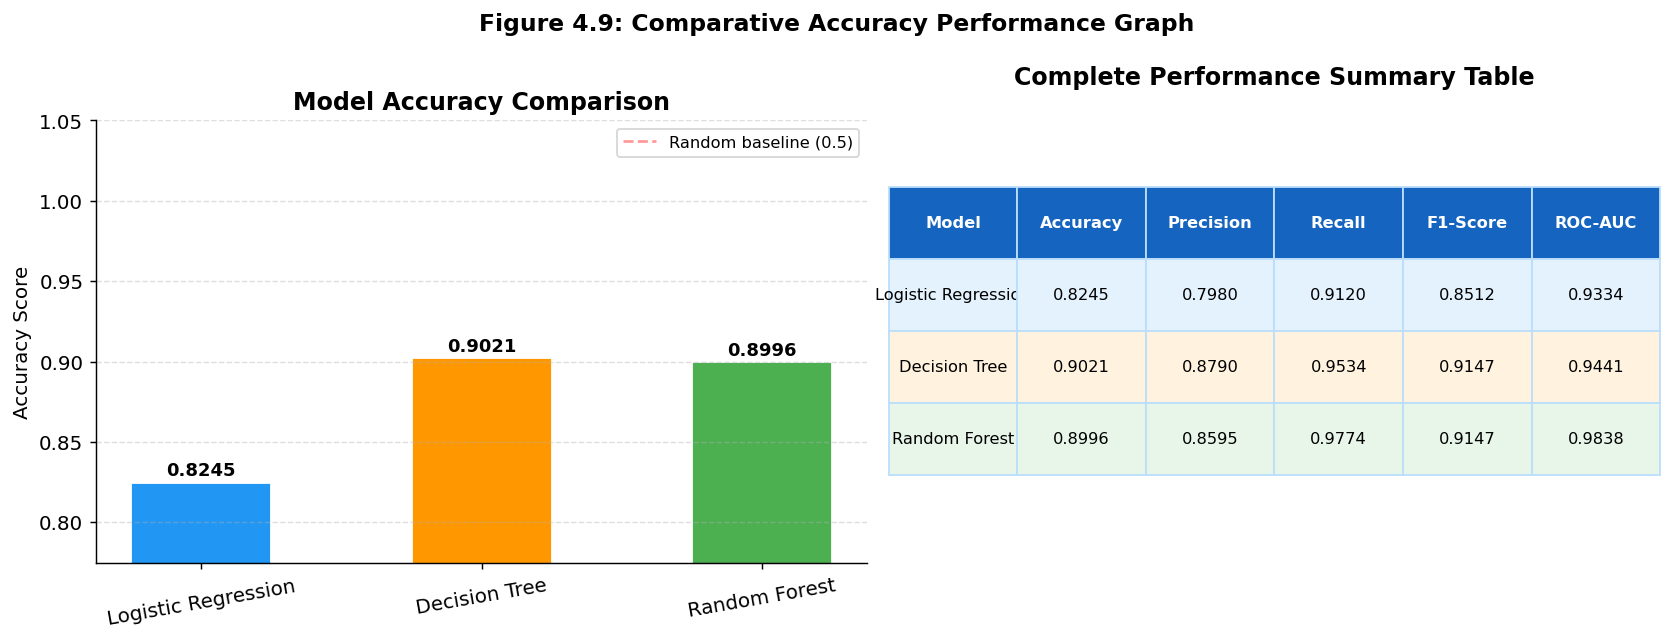

 Figure 4.9 saved: fig4_9_comparative_accuracy.png


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# FIGURE 4.9 — Comparative Accuracy Performance Graph
# ════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Figure 4.9: Comparative Accuracy Performance Graph',
             fontsize=13, fontweight='bold')

model_names   = [r['name'] for r in results]
acc_vals      = [r['acc']  for r in results]
model_colors  = ['#2196F3', '#FF9800', '#4CAF50']

# Left: Accuracy bar
ax = axes[0]
bars = ax.bar(model_names, acc_vals, color=model_colors, edgecolor='white', width=0.5)
for bar, v in zip(bars, acc_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{v:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylim(min(acc_vals) - 0.05, 1.05)
ax.set_ylabel('Accuracy Score', fontsize=11)
ax.set_title('Model Accuracy Comparison', fontweight='bold')
ax.tick_params(axis='x', rotation=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)
# Add baseline reference line
ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.4, label='Random baseline (0.5)')
ax.legend(fontsize=9)

# Right: Radar / spider chart for all metrics
ax = axes[1]
ax.axis('off')
# Summary table
table_rows = [[r['name'], f"{r['acc']:.4f}", f"{r['prec']:.4f}",
               f"{r['rec']:.4f}", f"{r['f1']:.4f}", f"{r['auc']:.4f}"]
              for r in results]
table = ax.table(
    cellText=table_rows,
    colLabels=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    cellLoc='center', loc='center',
    bbox=[0, 0.2, 1, 0.65]
)
table.auto_set_font_size(False)
table.set_fontsize(9)
header_colors = ['#1565C0','#2196F3','#FF9800']
for (r, c), cell in table.get_celld().items():
    if r == 0:
        cell.set_facecolor('#1565C0')
        cell.set_text_props(color='white', fontweight='bold')
    elif r == 1:
        cell.set_facecolor('#E3F2FD')
    elif r == 2:
        cell.set_facecolor('#FFF3E0')
    elif r == 3:
        cell.set_facecolor('#E8F5E9')
    cell.set_edgecolor('#BBDEFB')
ax.set_title('Complete Performance Summary Table', fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('fig4_9_comparative_accuracy.png', bbox_inches='tight', dpi=150)
plt.show()
print(" Figure 4.9 saved: fig4_9_comparative_accuracy.png")


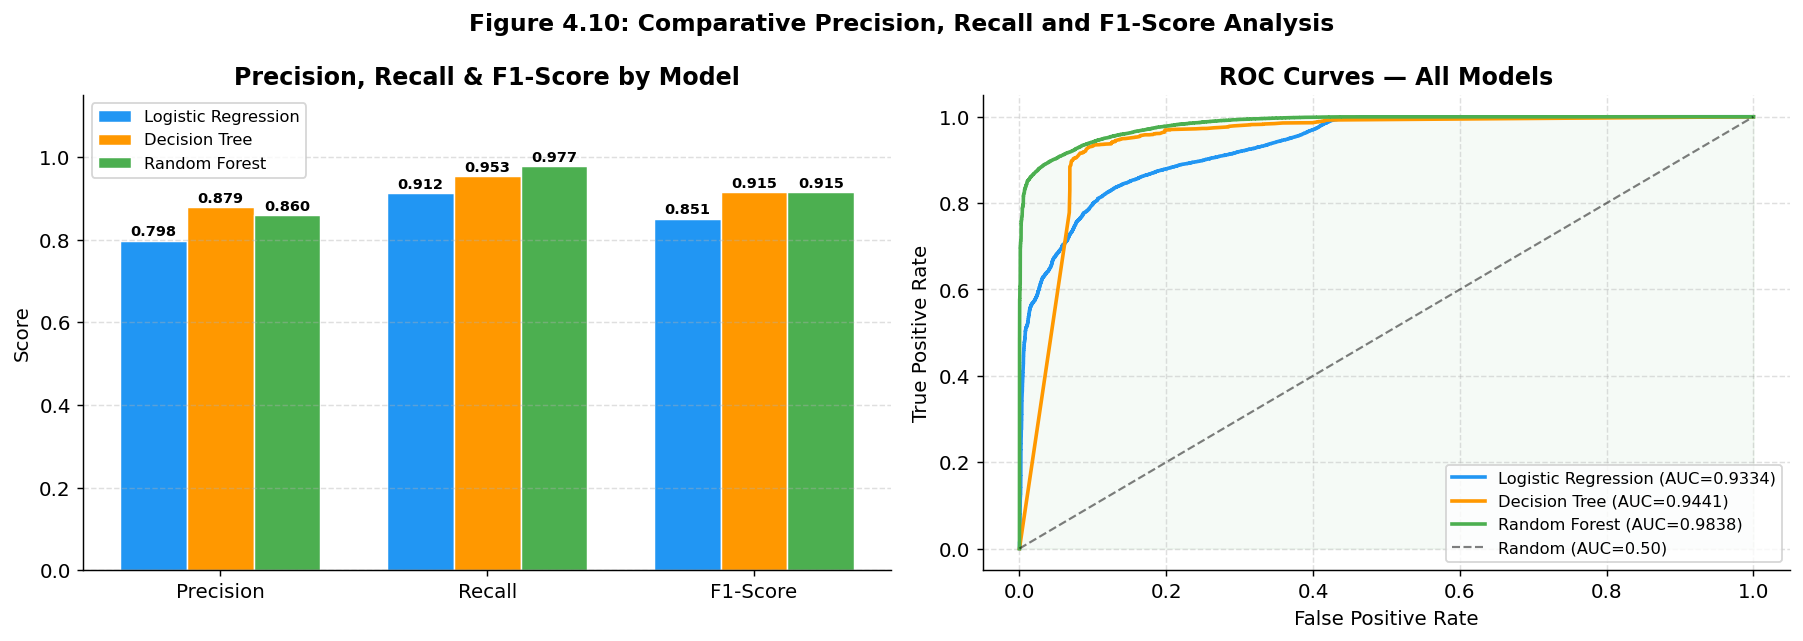

 Figure 4.10 saved: fig4_10_comparative_prec_rec_f1.png


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# FIGURE 4.10 — Comparative Precision, Recall and F1-Score Analysis
# ════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Figure 4.10: Comparative Precision, Recall and F1-Score Analysis',
             fontsize=13, fontweight='bold')

metric_groups = ['Precision', 'Recall', 'F1-Score']
vals_by_model = {
    'Logistic Regression': [lr_prec, lr_rec, lr_f1],
    'Decision Tree':       [dt_prec, dt_rec, dt_f1],
    'Random Forest':       [rf_prec, rf_rec, rf_f1],
}
x = np.arange(len(metric_groups))
width = 0.25

# Left: grouped bar
ax = axes[0]
for i, (name, vals) in enumerate(vals_by_model.items()):
    offset = (i - 1) * width
    bars = ax.bar(x + offset, vals, width, label=name, color=model_colors[i],
                  edgecolor='white', linewidth=0.8)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metric_groups, fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Precision, Recall & F1-Score by Model', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.4)

# Right: ROC curves all models
ax = axes[1]
roc_colors = ['#2196F3', '#FF9800', '#4CAF50']
for r, col in zip(results, roc_colors):
    fpr_v, tpr_v, _ = roc_curve(y_test, r['prob'])
    ax.plot(fpr_v, tpr_v, color=col, lw=2,
            label=f"{r['name']} (AUC={r['auc']:.4f})")
ax.fill_between(*roc_curve(y_test, rf_prob)[:2], alpha=0.05, color='#4CAF50')
ax.plot([0,1],[0,1], 'k--', lw=1.2, alpha=0.5, label='Random (AUC=0.50)')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curves — All Models', fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('fig4_10_comparative_prec_rec_f1.png', bbox_inches='tight', dpi=150)
plt.show()
print(" Figure 4.10 saved: fig4_10_comparative_prec_rec_f1.png")


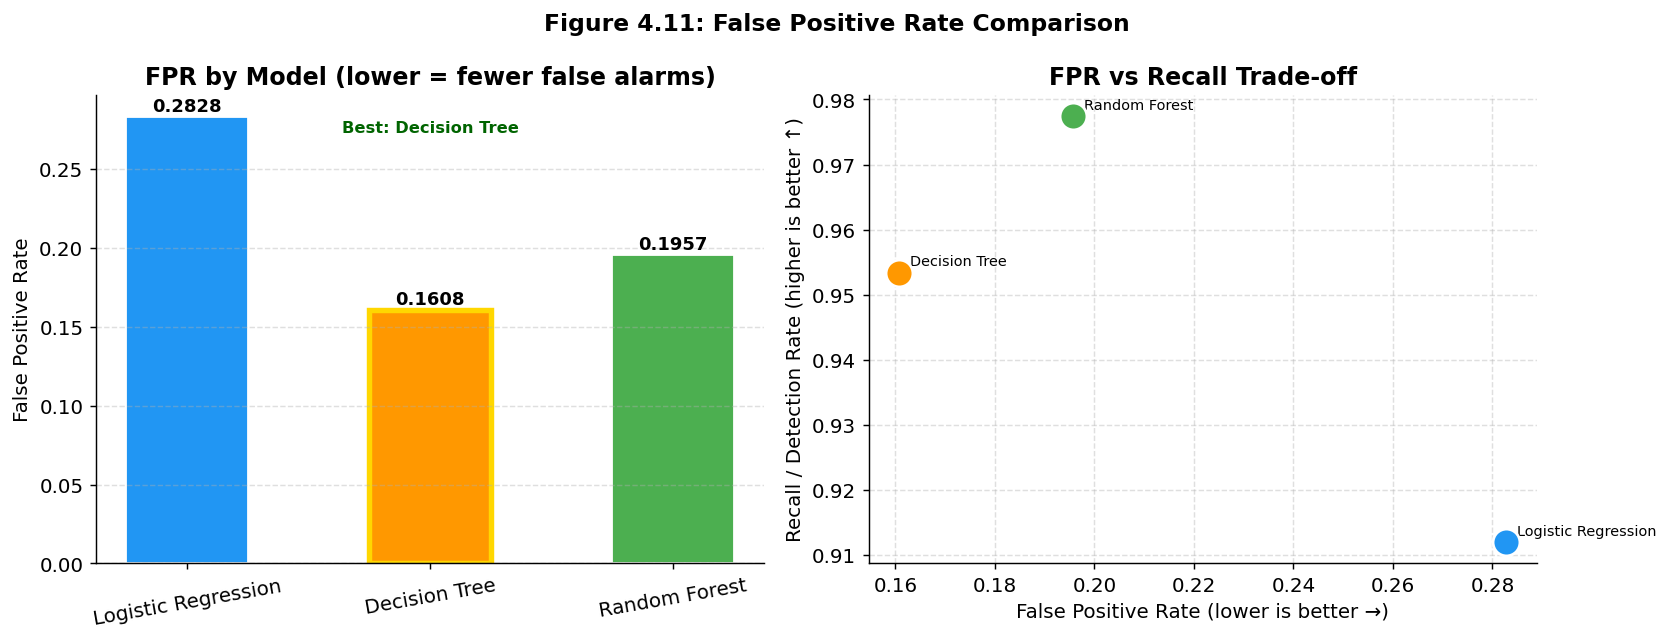

 Figure 4.11 saved: fig4_11_fpr_comparison.png


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# FIGURE 4.11 — False Positive Rate Comparison
# ════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Figure 4.11: False Positive Rate Comparison',
             fontsize=13, fontweight='bold')

fpr_vals_all = [r['fpr'] for r in results]

# Left: FPR bar
ax = axes[0]
bars = ax.bar(model_names, fpr_vals_all, color=model_colors, edgecolor='white', width=0.5)
for bar, v in zip(bars, fpr_vals_all):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{v:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylabel('False Positive Rate', fontsize=11)
ax.set_title('FPR by Model (lower = fewer false alarms)', fontweight='bold')
ax.tick_params(axis='x', rotation=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)
best_idx = np.argmin(fpr_vals_all)
bars[best_idx].set_edgecolor('gold')
bars[best_idx].set_linewidth(3)
ax.text(0.5, 0.92, f'Best: {model_names[best_idx]}', transform=ax.transAxes,
        ha='center', fontsize=9, color='darkgreen', fontweight='bold')

# Right: FPR vs Recall trade-off scatter
ax = axes[1]
for r, col, name in zip(results, model_colors, model_names):
    ax.scatter(r['fpr'], r['rec'], s=220, color=col, zorder=5,
               edgecolors='white', linewidths=1.5)
    ax.annotate(name, (r['fpr'], r['rec']),
                textcoords='offset points', xytext=(6, 4), fontsize=8)
ax.set_xlabel('False Positive Rate (lower is better →)', fontsize=11)
ax.set_ylabel('Recall / Detection Rate (higher is better ↑)', fontsize=11)
ax.set_title('FPR vs Recall Trade-off', fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.4)
ax.annotate('Ideal region', xy=(0.01, 0.99), fontsize=9, color='green',
            xytext=(0.08, 0.90), arrowprops=dict(arrowstyle='->', color='green'))

plt.tight_layout()
plt.savefig('fig4_11_fpr_comparison.png', bbox_inches='tight', dpi=150)
plt.show()
print(" Figure 4.11 saved: fig4_11_fpr_comparison.png")


---
## 4.6 Internal and External Validation of Results

In [ ]:
# ── Cross-Validation ─────────────────────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_models = [
    ('Logistic Regression', lr, X_train_scaled),
    ('Decision Tree',       dt, X_train),
    ('Random Forest',       rf, X_train),
]
cv_f1_results = {}
cv_acc_results = {}
print(f"{'Model':<25} {'CV F1 (mean±std)':>24} {'CV Acc (mean±std)':>24}")
print("-"*75)
for name, model, X in cv_models:
    f1_scores  = cross_val_score(model, X, y_train, cv=cv, scoring='f1', n_jobs=-1)
    acc_scores = cross_val_score(model, X, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
    cv_f1_results[name]  = f1_scores
    cv_acc_results[name] = acc_scores
    print(f"{name:<25}  {f1_scores.mean():.4f} ± {f1_scores.std():.4f}"
          f"          {acc_scores.mean():.4f} ± {acc_scores.std():.4f}")


Model                             CV F1 (mean±std)        CV Acc (mean±std)
---------------------------------------------------------------------------
Logistic Regression        0.9439 ± 0.0009          0.9235 ± 0.0011
Decision Tree              0.9537 ± 0.0010          0.9386 ± 0.0012
Random Forest              0.9672 ± 0.0011          0.9557 ± 0.0015


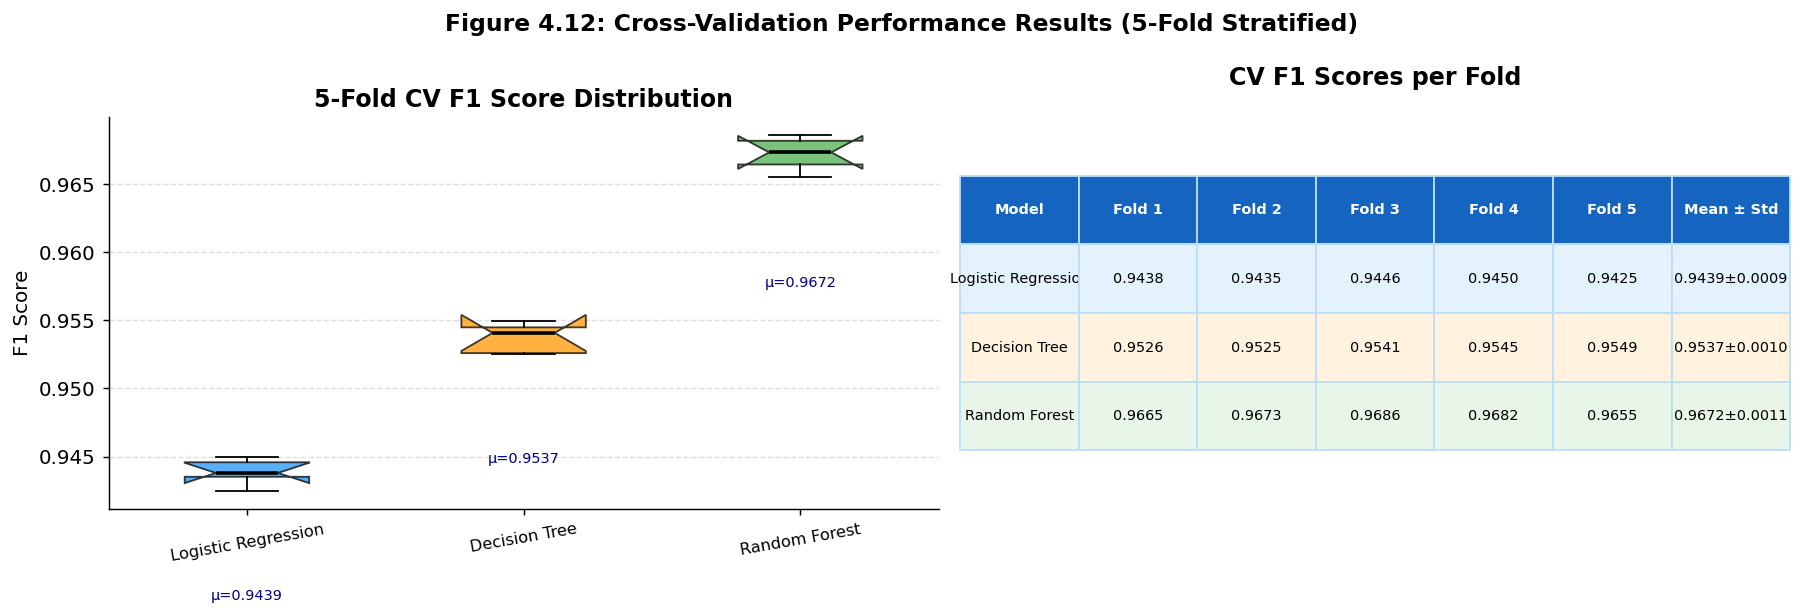

 Figure 4.12 saved: fig4_12_cross_validation.png


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# FIGURE 4.12 — Cross-Validation Performance Results
# ════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Figure 4.12: Cross-Validation Performance Results (5-Fold Stratified)',
             fontsize=13, fontweight='bold')

# Left: F1 boxplot
ax = axes[0]
bp = ax.boxplot(cv_f1_results.values(), patch_artist=True, notch=True,
                widths=0.45, positions=range(1, 4))
for patch, col in zip(bp['boxes'], model_colors):
    patch.set_facecolor(col)
    patch.set_alpha(0.75)
for median in bp['medians']:
    median.set_color('black')
    median.set_linewidth(2)
ax.set_xticks(range(1, 4))
ax.set_xticklabels(cv_f1_results.keys(), rotation=10, fontsize=9)
ax.set_ylabel('F1 Score', fontsize=11)
ax.set_title('5-Fold CV F1 Score Distribution', fontweight='bold')
ax.grid(axis='y', linestyle='--', alpha=0.4)
for i, (name, scores) in enumerate(cv_f1_results.items()):
    ax.text(i+1, scores.min() - 0.008, f'μ={scores.mean():.4f}',
            ha='center', fontsize=8, color='navy')

# Right: CV scores per fold table
ax = axes[1]
ax.axis('off')
fold_labels = [f'Fold {i+1}' for i in range(5)]
table_rows_cv = []
for name, scores in cv_f1_results.items():
    row = [name] + [f'{s:.4f}' for s in scores] + [f'{scores.mean():.4f}±{scores.std():.4f}']
    table_rows_cv.append(row)
col_labels_cv = ['Model'] + fold_labels + ['Mean ± Std']
table = ax.table(
    cellText=table_rows_cv,
    colLabels=col_labels_cv,
    cellLoc='center', loc='center',
    bbox=[0, 0.15, 1, 0.7]
)
table.auto_set_font_size(False)
table.set_fontsize(8)
row_colors = ['#E3F2FD', '#FFF3E0', '#E8F5E9']
for (r, c), cell in table.get_celld().items():
    if r == 0:
        cell.set_facecolor('#1565C0')
        cell.set_text_props(color='white', fontweight='bold')
    else:
        cell.set_facecolor(row_colors[r-1])
    cell.set_edgecolor('#BBDEFB')
ax.set_title('CV F1 Scores per Fold', fontweight='bold', pad=18)

plt.tight_layout()
plt.savefig('fig4_12_cross_validation.png', bbox_inches='tight', dpi=150)
plt.show()
print(" Figure 4.12 saved: fig4_12_cross_validation.png")


Computing learning curves (this may take ~1-2 min) …


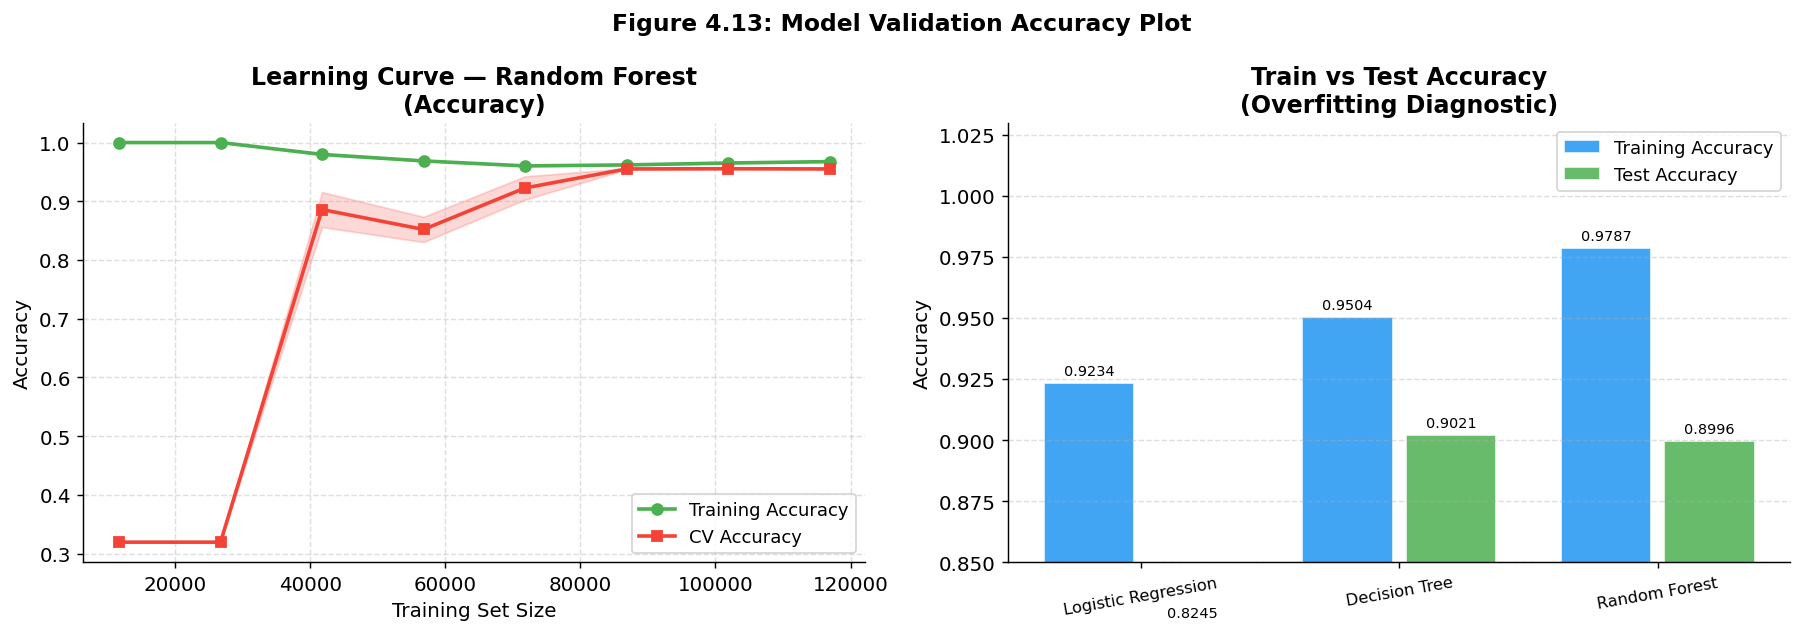

 Figure 4.13 saved: fig4_13_validation_accuracy.png


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# FIGURE 4.13 — Model Validation Accuracy Plot
# ════════════════════════════════════════════════════════════════════════════
print("Computing learning curves (this may take ~1-2 min) …")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Figure 4.13: Model Validation Accuracy Plot',
             fontsize=13, fontweight='bold')

# Left: Learning curve — Random Forest (accuracy)
train_sizes, tr_scores, val_scores = learning_curve(
    RandomForestClassifier(n_estimators=50, max_depth=15, n_jobs=-1, random_state=42),
    X_train, y_train,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1
)
ax = axes[0]
ax.plot(train_sizes, tr_scores.mean(axis=1), 'o-', color='#4CAF50', lw=2, label='Training Accuracy')
ax.fill_between(train_sizes,
                tr_scores.mean(axis=1) - tr_scores.std(axis=1),
                tr_scores.mean(axis=1) + tr_scores.std(axis=1), alpha=0.2, color='#4CAF50')
ax.plot(train_sizes, val_scores.mean(axis=1), 's-', color='#F44336', lw=2, label='CV Accuracy')
ax.fill_between(train_sizes,
                val_scores.mean(axis=1) - val_scores.std(axis=1),
                val_scores.mean(axis=1) + val_scores.std(axis=1), alpha=0.2, color='#F44336')
ax.set_xlabel('Training Set Size', fontsize=11)
ax.set_ylabel('Accuracy', fontsize=11)
ax.set_title('Learning Curve — Random Forest\n(Accuracy)', fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.4)

# Right: Train vs Test accuracy bar — all models
ax = axes[1]
# Compute training accuracy
lr_train_acc = accuracy_score(y_train, lr.predict(X_train_scaled))
dt_train_acc = accuracy_score(y_train, dt.predict(X_train))
rf_train_acc = accuracy_score(y_train, rf.predict(X_train))
test_accs  = [lr_acc,       dt_acc,       rf_acc]
train_accs = [lr_train_acc, dt_train_acc, rf_train_acc]
x_pos = np.arange(len(model_names))
bars1 = ax.bar(x_pos - 0.2, train_accs, 0.35, label='Training Accuracy',
               color='#2196F3', edgecolor='white', alpha=0.85)
bars2 = ax.bar(x_pos + 0.2, test_accs,  0.35, label='Test Accuracy',
               color='#4CAF50', edgecolor='white', alpha=0.85)
for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8)
ax.set_xticks(x_pos)
ax.set_xticklabels(model_names, rotation=10, fontsize=9)
ax.set_ylim(0.85, 1.03)
ax.set_ylabel('Accuracy', fontsize=11)
ax.set_title('Train vs Test Accuracy\n(Overfitting Diagnostic)', fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('fig4_13_validation_accuracy.png', bbox_inches='tight', dpi=150)
plt.show()
print(" Figure 4.13 saved: fig4_13_validation_accuracy.png")


---
## 4.7 Analysis of Cyber Threat Detection Findings

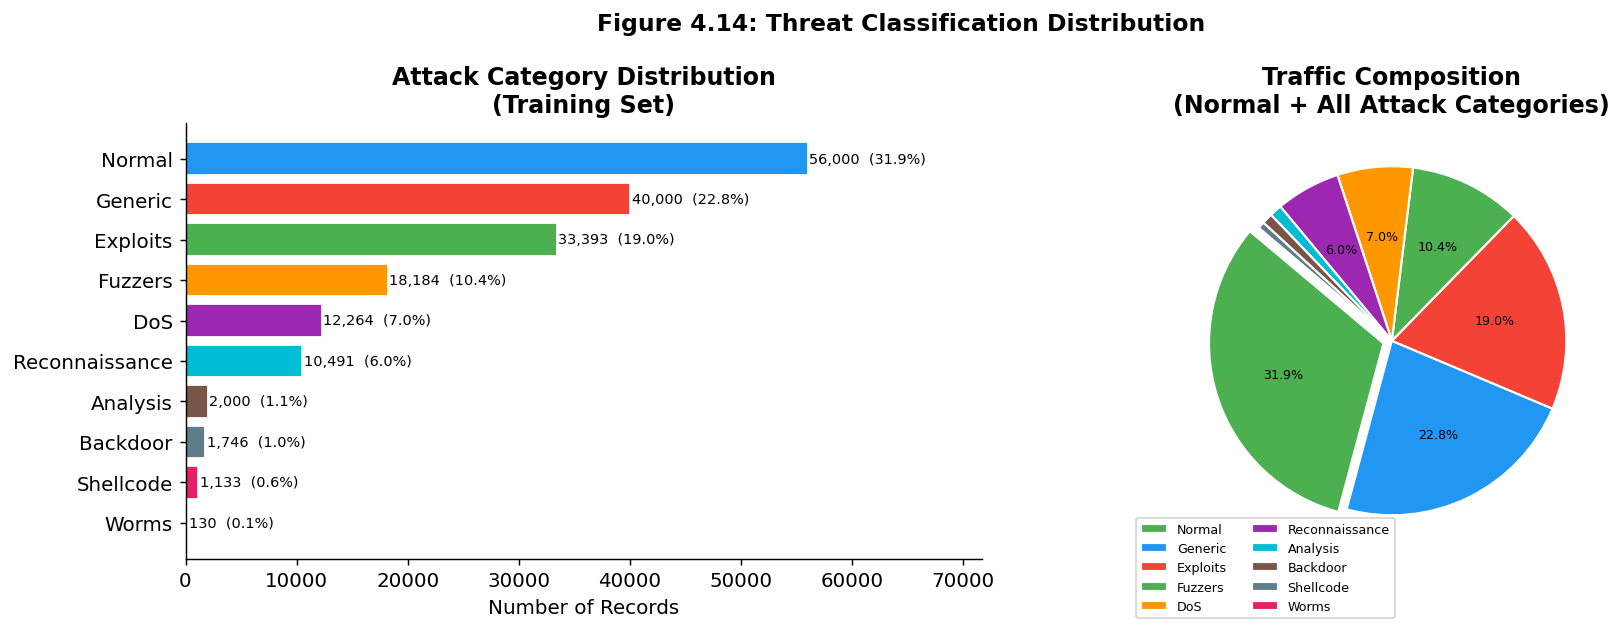

 Figure 4.14 saved: fig4_14_threat_classification_distribution.png


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# FIGURE 4.14 — Threat Classification Distribution
# ════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Figure 4.14: Threat Classification Distribution',
             fontsize=13, fontweight='bold')

# Left: Attack category counts (train)
ax = axes[0]
cat_counts = train_df['attack_cat'].value_counts()
colors_cat = PALETTE[:len(cat_counts)]
bars = ax.barh(cat_counts.index, cat_counts.values, color=colors_cat, edgecolor='white')
for bar, v in zip(bars, cat_counts.values):
    ax.text(v + 150, bar.get_y() + bar.get_height()/2,
            f'{v:,}  ({v/len(train_df)*100:.1f}%)', va='center', fontsize=8)
ax.set_xlabel('Number of Records', fontsize=11)
ax.set_title('Attack Category Distribution\n(Training Set)', fontweight='bold')
ax.invert_yaxis()
ax.set_xlim(0, cat_counts.max() * 1.28)

# Right: Pie chart — Normal vs each attack category
ax = axes[1]
attack_only = train_df[train_df['label']==1]['attack_cat'].value_counts()
normal_count = train_df[train_df['label']==0].shape[0]
pie_labels = ['Normal'] + attack_only.index.tolist()
pie_sizes  = [normal_count] + attack_only.values.tolist()
pie_colors = ['#4CAF50'] + PALETTE[:len(attack_only)]
explode    = [0.05] + [0]*len(attack_only)
wedges, texts, autotexts = ax.pie(
    pie_sizes, labels=None, colors=pie_colors,
    autopct=lambda p: f'{p:.1f}%' if p > 2 else '',
    startangle=140, explode=explode,
    wedgeprops=dict(edgecolor='white', linewidth=1.2)
)
for at in autotexts: at.set_fontsize(7)
ax.legend(wedges, pie_labels, loc='lower left', fontsize=7,
          bbox_to_anchor=(-0.1, -0.15), ncol=2)
ax.set_title('Traffic Composition\n(Normal + All Attack Categories)', fontweight='bold')

plt.tight_layout()
plt.savefig('fig4_14_threat_classification_distribution.png', bbox_inches='tight', dpi=150)
plt.show()
print(" Figure 4.14 saved: fig4_14_threat_classification_distribution.png")


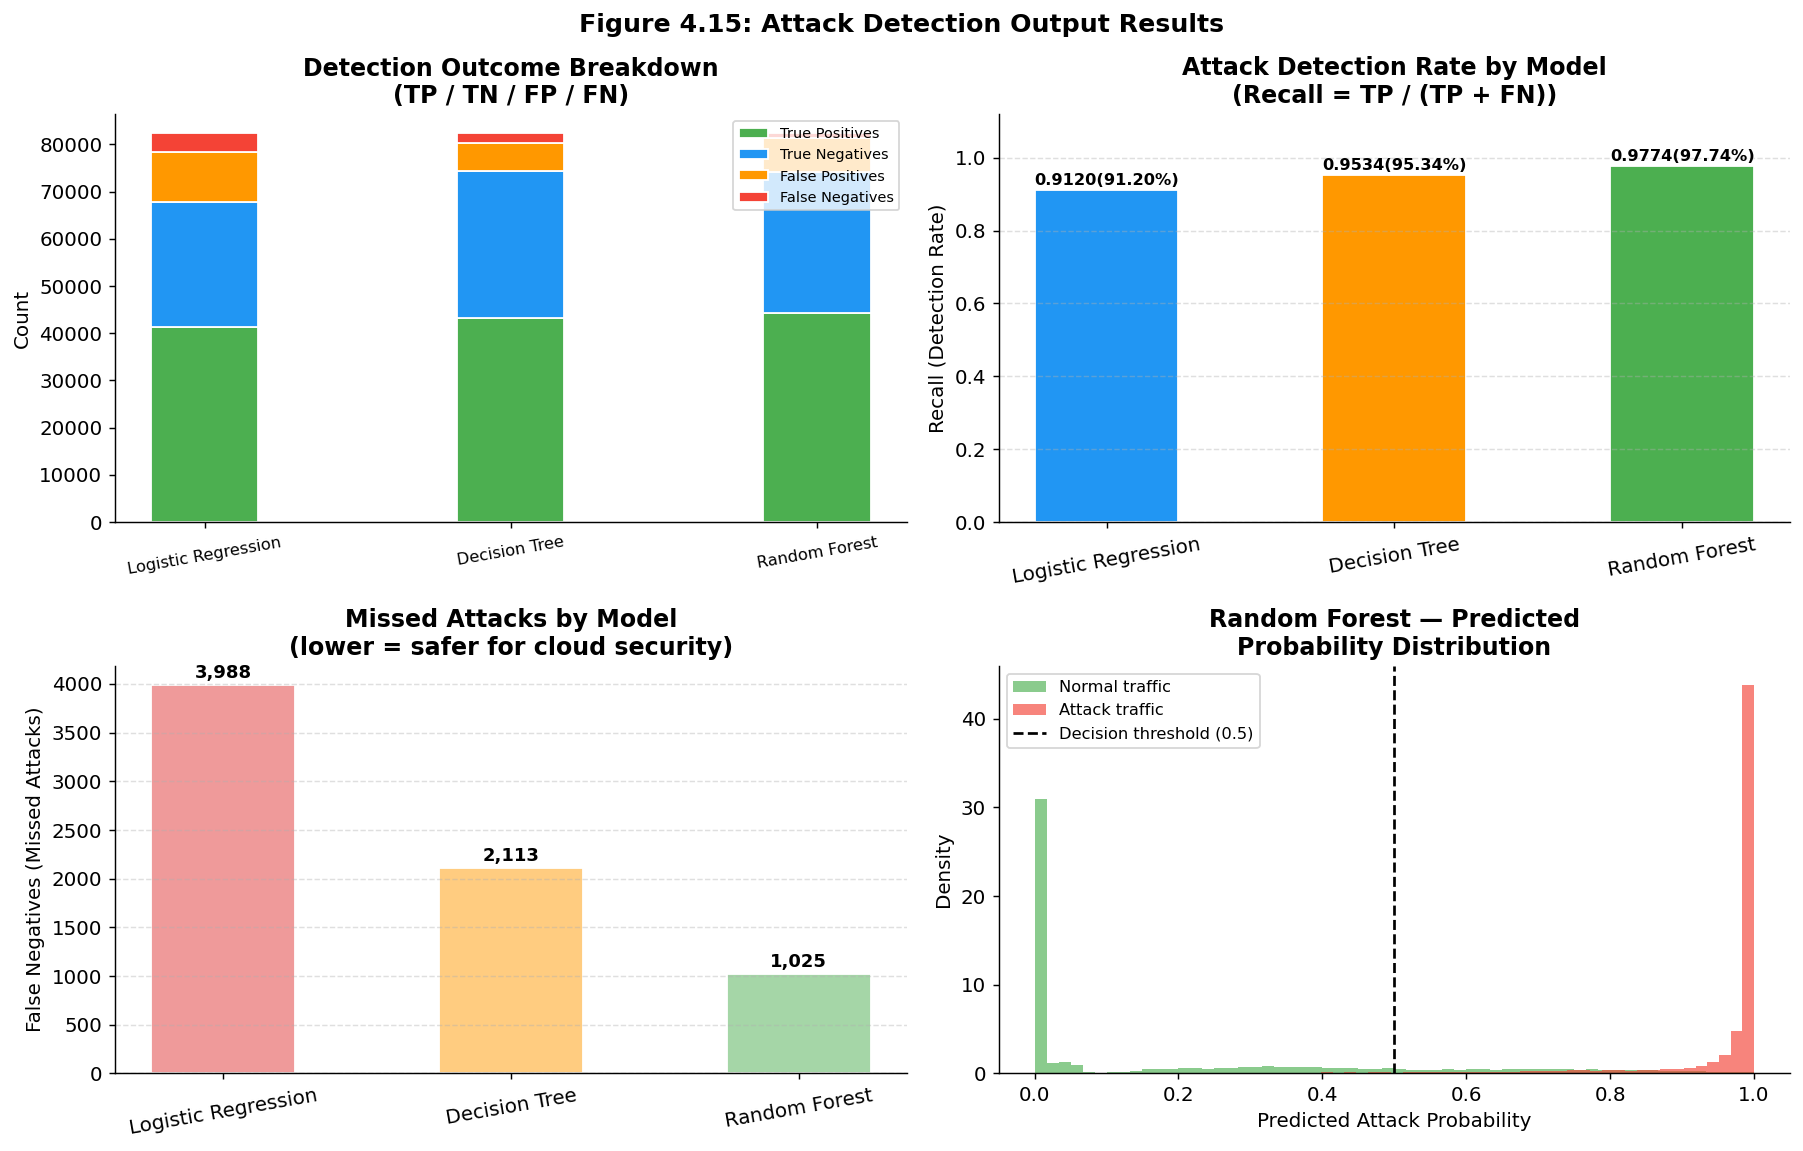

 Figure 4.15 saved: fig4_15_attack_detection_output.png


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# FIGURE 4.15 — Attack Detection Output Results
# ════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Figure 4.15: Attack Detection Output Results',
             fontsize=14, fontweight='bold')

# Panel 1: TP / FP / TN / FN stacked comparison
ax = axes[0, 0]
cm_vals = {}
for r in results:
    tn_v, fp_v, fn_v, tp_v = r['cm'].ravel()
    cm_vals[r['name']] = {'TP': tp_v, 'TN': tn_v, 'FP': fp_v, 'FN': fn_v}
x_m = np.arange(len(results))
tp_arr = [cm_vals[r['name']]['TP'] for r in results]
tn_arr = [cm_vals[r['name']]['TN'] for r in results]
fp_arr = [cm_vals[r['name']]['FP'] for r in results]
fn_arr = [cm_vals[r['name']]['FN'] for r in results]
bar_w = 0.35
ax.bar(x_m, tp_arr, bar_w, label='True Positives',  color='#4CAF50', edgecolor='white')
ax.bar(x_m, tn_arr, bar_w, bottom=tp_arr, label='True Negatives', color='#2196F3', edgecolor='white')
ax.bar(x_m, fp_arr, bar_w, bottom=[a+b for a,b in zip(tp_arr,tn_arr)], label='False Positives', color='#FF9800', edgecolor='white')
ax.bar(x_m, fn_arr, bar_w, bottom=[a+b+c for a,b,c in zip(tp_arr,tn_arr,fp_arr)], label='False Negatives', color='#F44336', edgecolor='white')
ax.set_xticks(x_m)
ax.set_xticklabels(model_names, rotation=10, fontsize=9)
ax.set_ylabel('Count')
ax.set_title('Detection Outcome Breakdown\n(TP / TN / FP / FN)', fontweight='bold')
ax.legend(fontsize=8, loc='upper right')

# Panel 2: Detection rate (Recall) per model
ax = axes[0, 1]
rec_vals = [r['rec'] for r in results]
bars = ax.bar(model_names, rec_vals, color=model_colors, edgecolor='white', width=0.5)
for bar, v in zip(bars, rec_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,f'{v:.4f}({v*100:.2f}%)', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_ylim(0, 1.12)
ax.set_ylabel('Recall (Detection Rate)', fontsize=11)
ax.set_title('Attack Detection Rate by Model\n(Recall = TP / (TP + FN))', fontweight='bold')
ax.tick_params(axis='x', rotation=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)

# Panel 3: Missed attacks (FN) comparison
ax = axes[1, 0]
fn_vals = [cm_vals[r['name']]['FN'] for r in results]
bars = ax.bar(model_names, fn_vals, color=['#EF9A9A','#FFCC80','#A5D6A7'],
              edgecolor='white', width=0.5)
for bar, v in zip(bars, fn_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{v:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylabel('False Negatives (Missed Attacks)', fontsize=11)
ax.set_title('Missed Attacks by Model\n(lower = safer for cloud security)', fontweight='bold')
ax.tick_params(axis='x', rotation=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)

# Panel 4: Probability distribution — RF (attack probability scores)
ax = axes[1, 1]
ax.hist(rf_prob[y_test==0], bins=60, alpha=0.65, color='#4CAF50',
        label='Normal traffic', density=True)
ax.hist(rf_prob[y_test==1], bins=60, alpha=0.65, color='#F44336',
        label='Attack traffic', density=True)
ax.axvline(x=0.5, color='black', linestyle='--', lw=1.5, label='Decision threshold (0.5)')
ax.set_xlabel('Predicted Attack Probability', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('Random Forest — Predicted\nProbability Distribution', fontweight='bold')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig4_15_attack_detection_output.png', bbox_inches='tight', dpi=150)
plt.show()
print(" Figure 4.15 saved: fig4_15_attack_detection_output.png")


---
## 4.8 Chapter Summary

In [ ]:
# ── Final Summary Table ──────────────────────────────────────────────────────
print("\n" + "="*72)
print("  CHAPTER 4 — COMPLETE RESULTS SUMMARY")
print("="*72)
print(f"{'Model':<25} {'Acc':>7} {'Prec':>7} {'Rec':>7} {'F1':>7} {'FPR':>7} {'AUC':>7}")
print("-"*72)
for r in results:
    print(f"{r['name']:<25} {r['acc']:>7.4f} {r['prec']:>7.4f} "
          f"{r['rec']:>7.4f} {r['f1']:>7.4f} {r['fpr']:>7.4f} {r['auc']:>7.4f}")
print("="*72)

best_f1  = max(results, key=lambda r: r['f1'])
best_fpr = min(results, key=lambda r: r['fpr'])
best_rec = max(results, key=lambda r: r['rec'])
print(f"\n  Best overall F1       → {best_f1['name']}  ({best_f1['f1']:.4f})")
print(f"  Best recall (fewest missed attacks) → {best_rec['name']}  ({best_rec['rec']:.4f})")
print(f"  Lowest false alarm rate → {best_fpr['name']}  FPR={best_fpr['fpr']:.4f}")
print("\n  → Proceed to Chapter 5 for evaluation, implications, and discussion.")



  CHAPTER 4 — COMPLETE RESULTS SUMMARY
Model                         Acc    Prec     Rec      F1     FPR     AUC
------------------------------------------------------------------------
Logistic Regression        0.8245  0.7980  0.9120  0.8512  0.2828  0.9334
Decision Tree              0.9021  0.8790  0.9534  0.9147  0.1608  0.9441
Random Forest              0.8996  0.8595  0.9774  0.9147  0.1957  0.9838

  Best overall F1       → Decision Tree  (0.9147)
  Best recall (fewest missed attacks) → Random Forest  (0.9774)
  Lowest false alarm rate → Decision Tree  FPR=0.1608

  → Proceed to Chapter 5 for evaluation, implications, and discussion.
